In [103]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# === 1. Load data ===
df = pd.read_csv("Dataset/B90_102_exp30m_202104.csv")

# === 2. Convert time to datetime and sort ===
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

# === 3. Keep required columns (including time) ===
cols = [
    "time",
    "room_temp",
    "thermostat_outside_temp",
    "damper_position",
    "airflow_current",
    "supply_discharge_temp",
    "clg_signal",
    "htg_signal",
    "htg_valve_position",
    "clg_sp_current",
    "htg_sp_current",
    "htg_clg_mode"
]

df = df[cols].copy()

# === 4. Create active setpoint ===
df["setpoint"] = (
    df["htg_clg_mode"] * df["htg_sp_current"] +
    (1 - df["htg_clg_mode"]) * df["clg_sp_current"]
)

# === 5. Create thermal signal ===
df["thermal_signal"] = (
    df["htg_clg_mode"] * df["htg_signal"] +
    (1 - df["htg_clg_mode"]) * df["clg_signal"]
)

# === 6. Drop separate setpoints ===
df = df.drop(columns=["clg_sp_current", "htg_sp_current"])

# === 7. Normalize numeric columns ===
num_cols = [
    "room_temp",
    "thermostat_outside_temp",
    "damper_position",
    "airflow_current",
    "supply_discharge_temp",
    "clg_signal",
    "htg_signal",
    "htg_valve_position",
    "setpoint",
    "thermal_signal"
]

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# === 8. Set time as index ===
df = df.set_index("time")

# === 9. Drop NA and ensure ascending ===
df = df.dropna().sort_index()
print(df.head())

                     room_temp  thermostat_outside_temp  damper_position  \
time                                                                       
2021-04-26 09:37:00   0.527778                    0.375              0.0   
2021-04-26 09:38:00   0.513889                    0.375              0.0   
2021-04-26 09:39:00   0.513889                    0.375              0.0   
2021-04-26 09:40:00   0.500000                    0.375              0.0   
2021-04-26 09:41:00   0.472222                    0.375              0.0   

                     airflow_current  supply_discharge_temp  clg_signal  \
time                                                                      
2021-04-26 09:37:00         0.036125               0.075980    0.890997   
2021-04-26 09:38:00         0.031199               0.063725    0.927331   
2021-04-26 09:39:00         0.041051               0.056373    0.963666   
2021-04-26 09:40:00         0.026273               0.049020    1.000000   
2021-04-26 09:41:

In [104]:
# Save transformed dataset
output_path = "Dataset/Transformed_1.csv"
df.to_csv(output_path, index=False)

print("Transformed dataset saved at:", output_path)

Transformed dataset saved at: Dataset/Transformed_1.csv


In [121]:

class HVACEnv:
    def __init__(self, data_path, damper_step=0.05, lam=0.5):
        # Load transformed dataset
        self.df = pd.read_csv(data_path)
        self.df = self.df.reset_index(drop=True)

        self.damper_step = damper_step
        self.lam = lam
        self.max_index = len(self.df) - 1

        # Cache column indices for speed
        self.damper_idx = self.df.columns.get_loc("damper_position")
        self.airflow_idx = self.df.columns.get_loc("airflow_current")
        self.room_idx = self.df.columns.get_loc("room_temp")
        self.setpoint_idx = self.df.columns.get_loc("setpoint")
        self.signal_idx = self.df.columns.get_loc("thermal_signal")

        self.reset()

    def reset(self, start_idx=None):

        if start_idx is not None:
            # sequential training start
            self.idx = int(start_idx)
        else:
            # random valid start (old behavior)
            valid_indices = np.where(self.df["damper_position"].values > 0)[0]
            self.idx = int(np.random.choice(valid_indices))

        self.current_damper = self.df.iloc[self.idx]["damper_position"]
        return self._get_state()

    def _get_state(self):
        return self.df.iloc[self.idx].values.astype(np.float32)

    def step(self, action):

        # update damper
        if action == 0:
            self.current_damper -= self.damper_step
        elif action == 2:
            self.current_damper += self.damper_step

        self.current_damper = np.clip(self.current_damper, 0.0, 1.0)

        # safe move
        self.idx += 1
        if self.idx >= self.max_index:
            self.idx = self.max_index
            done = True
        else:
            done = False

        row = self.df.iloc[self.idx]

        base_damper = max(row["damper_position"], 1e-3)
        ratio = self.current_damper / base_damper
        ratio = np.clip(ratio, 0.2, 2.0)

        airflow = row["airflow_current"] * ratio
        airflow = np.clip(airflow, 0.0, 1.0)
        thermal_signal = row["thermal_signal"]
        energy = airflow * thermal_signal

        temp_error = abs(row["room_temp"] - row["setpoint"])
        reward = -temp_error - self.lam * energy

        next_state = row.values.astype(np.float32).copy()
        next_state[self.damper_idx] = self.current_damper

        return next_state, reward, done, {"energy": energy}

In [124]:
import numpy as np

env = HVACEnv("Dataset/Transformed.csv")

state = env.reset()
print("State length:", len(state))
print("Initial damper:", state[env.damper_idx])

for i in range(5):
    action = np.random.choice([0,1,2])
    next_state, reward, done, info = env.step(action)

    print(f"\nStep {i+1}")
    print("Action:", action)
    print("Damper:", next_state[env.damper_idx])
    print("Airflow:", next_state[env.airflow_idx])
    print("Energy:", info["energy"])
    print("Reward:", reward)

State length: 11
Initial damper: 0.7692307

Step 1
Action: 1
Damper: 0.7692307
Airflow: 0.79310346
Energy: 0.5679874314965516
Reward: -0.3951048268593865

Step 2
Action: 1
Damper: 0.7692307
Airflow: 0.77832514
Energy: 0.5725988062931947
Reward: -0.39741051425770807

Step 3
Action: 2
Damper: 0.8192307
Airflow: 0.76683086
Energy: 0.5965878696256007
Reward: -0.4094050459239111

Step 4
Action: 1
Damper: 0.8192307
Airflow: 0.7619048
Energy: 0.6095782815880391
Reward: -0.41590025190513025

Step 5
Action: 0
Damper: 0.7692307
Airflow: 0.74712646
Energy: 0.5572694878210108
Reward: -0.3897458550216161


In [125]:
env.idx = 1080  # or any later index
state = env._get_state()

for i in range(5):
    s, r, d, info = env.step(np.random.choice([0,1,2]))
    print(s[env.damper_idx], s[env.airflow_idx], info["energy"])

0.7192307 0.37931034 0.24262515366896548
0.7192307 0.35303777 0.21540534483087026
0.7192307 0.34811166 0.20195639222463052
0.7692307 0.3579639 0.19693333216880127
0.8192307 0.32676518 0.16980321923185546


In [126]:
print(env.df["damper_position"].describe())
print(env.df["airflow_current"].describe())

count    5747.000000
mean        0.319941
std         0.252732
min         0.000000
25%         0.102564
50%         0.282051
75%         0.487180
max         1.000000
Name: damper_position, dtype: float64
count    5747.000000
mean        0.326173
std         0.257905
min         0.000000
25%         0.067323
50%         0.295567
75%         0.509031
max         1.000000
Name: airflow_current, dtype: float64


In [127]:
import numpy as np
import copy

class MCTSNode:
    def __init__(self, state, parent=None):
        self.state = state
        self.parent = parent
        self.children = {}
        self.visits = 0
        self.value = 0.0


class MCTS:
    def __init__(self, env, simulations=30, c_puct=1.0):
        self.env = env
        self.simulations = simulations
        self.c_puct = c_puct
        self.actions = [0, 1, 2]  # decrease, hold, increase

    def search(self, root_state):
        root = MCTSNode(root_state)

        for _ in range(self.simulations):
            env_copy = copy.deepcopy(self.env)
            node = root

            # --- Selection ---
            while node.children:
                action, node = self._select(node)
                _, reward, done, _ = env_copy.step(action)
                if done:
                    break

            # --- Expansion ---
            if not node.children:
                for a in self.actions:
                    env_tmp = copy.deepcopy(env_copy)
                    next_state, reward, done, _ = env_tmp.step(a)
                    node.children[a] = MCTSNode(next_state, parent=node)

            # --- Rollout ---
            value = self._rollout(env_copy)

            # --- Backprop ---
            self._backprop(node, value)

        # choose best action
        best_action = max(root.children.items(),
                          key=lambda x: x[1].visits)[0]

        return best_action

    def _select(self, node):
        best_score = -np.inf
        best_action = None
        best_child = None

        for action, child in node.children.items():
            ucb = (
                child.value / (child.visits + 1e-6)
                + self.c_puct * np.sqrt(np.log(node.visits + 1) / (child.visits + 1))
            )
            if ucb > best_score:
                best_score = ucb
                best_action = action
                best_child = child

        return best_action, best_child

    def _rollout(self, env_copy, depth=5):
        total_reward = 0
        for _ in range(depth):
            action = np.random.choice(self.actions)
            _, reward, done, _ = env_copy.step(action)
            total_reward += reward
            if done:
                break
        return total_reward

    def _backprop(self, node, value):
        while node is not None:
            node.visits += 1
            node.value += value
            node = node.parent

In [128]:
import numpy as np

env = HVACEnv("Dataset/Transformed.csv")
mcts = MCTS(env, simulations=30)

# start from row 1000
env.idx = 1
state = env._get_state()

print("Start index:", env.idx)
print("Initial damper:", state[env.damper_idx])
print("Initial airflow:", state[env.airflow_idx])

# run few MCTS decisions
for step in range(5):
    action = mcts.search(state)

    next_state, reward, done, info = env.step(action)

    print(f"\nStep {step+1}")
    print("MCTS action:", action)
    print("Damper:", next_state[env.damper_idx])
    print("Airflow:", next_state[env.airflow_idx])
    print("Energy:", info["energy"])
    print("Reward:", reward)

    state = next_state

    if done:
        print("Episode finished")
        break

Start index: 1
Initial damper: 0.0
Initial airflow: 0.031198686

Step 1
MCTS action: 0
Damper: 0.28333333
Airflow: 0.041050903
Energy: 0.010884909794745448
Reward: -0.081831343786262

Step 2
MCTS action: 0
Damper: 0.23333333
Airflow: 0.026272578
Energy: 0.007229003906732308
Reward: -0.06611450195336438

Step 3
MCTS action: 0
Damper: 0.18333334
Airflow: 0.01642036
Energy: 0.0027009033802955574
Reward: -0.03607267391237099

Step 4
MCTS action: 0
Damper: 0.13333334
Airflow: 0.02134647
Energy: 0.003550300034581266
Reward: -0.022608483350622727

Step 5
MCTS action: 0
Damper: 0.083333336
Airflow: 0.026272578
Energy: 0.004369600042561555
Reward: -0.02301813335461287


In [129]:
import torch
import torch.nn as nn
import torch.nn.functional as F

STATE_SIZE = 11   # your state length
ACTION_SIZE = 3   # damper: decrease, hold, increase


class AlphaThermalNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(STATE_SIZE, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.policy_head = nn.Linear(64, ACTION_SIZE)
        self.value_head = nn.Linear(64, 1)

    def forward(self, x):
        x = self.shared(x)

        policy_logits = self.policy_head(x)
        policy = F.softmax(policy_logits, dim=1)

        value = torch.tanh(self.value_head(x))

        return policy, value

In [130]:
import numpy as np
import copy
import torch


class MCTSNode:
    def __init__(self, state, parent=None):
        self.state = state
        self.parent = parent
        self.children = {}
        self.visits = 0
        self.value = 0.0


class MCTS:
    def __init__(self, env, model, simulations=30, c_puct=1.0):
        self.env = env
        self.model = model
        self.simulations = simulations
        self.c_puct = c_puct
        self.actions = [0, 1, 2]

    def search(self, root_state):
        root = MCTSNode(root_state)

        for _ in range(self.simulations):
            env_copy = copy.deepcopy(self.env)
            node = root

            # --- Selection ---
            while node.children:
                action, node = self._select(node)
                _, _, done, _ = env_copy.step(action)
                if done:
                    break

            # --- Expansion ---
            if not node.children:
                for a in self.actions:
                    env_tmp = copy.deepcopy(env_copy)
                    next_state, _, _, _ = env_tmp.step(a)
                    node.children[a] = MCTSNode(next_state, parent=node)

            # --- Evaluation using neural net ---
            value = self._evaluate(env_copy)

            # --- Backprop ---
            self._backprop(node, value)

        best_action = max(root.children.items(),
                          key=lambda x: x[1].visits)[0]

        return best_action

    def _select(self, node):
        best_score = -np.inf
        best_action = None
        best_child = None

        for action, child in node.children.items():
            ucb = (
                child.value / (child.visits + 1e-6)
                + self.c_puct * np.sqrt(np.log(node.visits + 1) / (child.visits + 1))
            )
            if ucb > best_score:
                best_score = ucb
                best_action = action
                best_child = child

        return best_action, best_child

    def _evaluate(self, env_copy):
        state = env_copy._get_state()
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            _, value = self.model(s)

        return value.item()

    def _backprop(self, node, value):
        while node is not None:
            node.visits += 1
            node.value += value
            node = node.parent

In [131]:
env = HVACEnv("Dataset/Transformed.csv")
model = AlphaThermalNet()

state = env.reset()

print("Initial damper:", state[env.damper_idx])

# NN forward
s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
policy, value = model(s)

print("NN policy:", policy.detach().numpy())
print("NN value:", value.item())

# MCTS decision
mcts = MCTS(env, model, simulations=20)
action = mcts.search(state)

print("MCTS action:", action)

next_state, reward, done, info = env.step(action)

print("Next damper:", next_state[env.damper_idx])
print("Energy:", info["energy"])
print("Reward:", reward)

Initial damper: 0.025640931
NN policy: [[0.35216647 0.33160317 0.31623042]]
NN value: -0.040401484817266464
MCTS action: 0
Next damper: 0.0
Energy: 0.0
Reward: -0.2430555555555554


In [132]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- hyperparams ---
EPISODES = 10
STEPS_PER_EPISODE = 200
LR = 1e-3

env = HVACEnv("Dataset/Transformed.csv")
model = AlphaThermalNet()
optimizer = optim.Adam(model.parameters(), lr=LR)

mcts = MCTS(env, model, simulations=20)

# storage
memory_states = []
memory_policies = []
memory_values = []

for ep in range(EPISODES):
    state = env.reset()

    episode_states = []
    episode_rewards = []
    episode_policies = []

    for step in range(STEPS_PER_EPISODE):

        # --- MCTS search ---
        action = mcts.search(state)

        # create one-hot policy target
        policy_target = np.zeros(3)
        policy_target[action] = 1.0

        next_state, reward, done, _ = env.step(action)

        episode_states.append(state)
        episode_policies.append(policy_target)
        episode_rewards.append(reward)

        state = next_state
        if done:
            break

    # --- compute value targets (returns) ---
    returns = []
    G = 0
    for r in reversed(episode_rewards):
        G = r + 0.99 * G
        returns.insert(0, G)

    memory_states.extend(episode_states)
    memory_policies.extend(episode_policies)
    memory_values.extend(returns)

    print(f"Episode {ep+1} collected")

# ===== TRAIN NETWORK =====
states = torch.tensor(np.array(memory_states), dtype=torch.float32)
policies = torch.tensor(np.array(memory_policies), dtype=torch.float32)
values = torch.tensor(np.array(memory_values), dtype=torch.float32).unsqueeze(1)

for epoch in range(20):

    pred_policy, pred_value = model(states)

    # losses
    policy_loss = -(policies * torch.log(pred_policy + 1e-8)).sum(dim=1).mean()
    value_loss = nn.MSELoss()(pred_value, values)

    loss = policy_loss + value_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} loss:", loss.item())

Episode 1 collected
Episode 2 collected
Episode 3 collected
Episode 4 collected
Episode 5 collected
Episode 6 collected
Episode 7 collected
Episode 8 collected
Episode 9 collected
Episode 10 collected
Epoch 1 loss: 72.56340789794922
Epoch 2 loss: 72.21624755859375
Epoch 3 loss: 71.87825012207031
Epoch 4 loss: 71.5484390258789
Epoch 5 loss: 71.2251968383789
Epoch 6 loss: 70.90888214111328
Epoch 7 loss: 70.59928131103516
Epoch 8 loss: 70.2966079711914
Epoch 9 loss: 69.9971923828125
Epoch 10 loss: 69.69715881347656
Epoch 11 loss: 69.3939437866211
Epoch 12 loss: 69.08602142333984
Epoch 13 loss: 68.77268981933594
Epoch 14 loss: 68.45411682128906
Epoch 15 loss: 68.12946319580078
Epoch 16 loss: 67.7999267578125
Epoch 17 loss: 67.46573638916016
Epoch 18 loss: 67.12458038330078
Epoch 19 loss: 66.77719116210938
Epoch 20 loss: 66.42568969726562


In [133]:
state = env.reset()
mcts = MCTS(env, model, simulations=50)

for _ in range(5):
    action = mcts.search(state)
    state, reward, _, info = env.step(action)
    print("Damper:", state[env.damper_idx], "Energy:", info["energy"])

Damper: 0.43717954 Energy: 0.2690902505959657
Damper: 0.38717952 Energy: 0.24485948368757027
Damper: 0.33717954 Energy: 0.2151530001730293
Damper: 0.28717953 Energy: 0.18813353646787823
Damper: 0.23717953 Energy: 0.13657823563377194


In [134]:
import pandas as pd

df = pd.read_csv("Dataset/Transformed.csv")

split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df  = df.iloc[split_idx:].reset_index(drop=True)

train_df.to_csv("Dataset/Train.csv", index=False)
test_df.to_csv("Dataset/Test.csv", index=False)

print("Train:", len(train_df), "Test:", len(test_df))

Train: 4022 Test: 1725


In [137]:
import torch
import numpy as np

# --- load train data ---
train_env = HVACEnv("Dataset/Train.csv")
model = AlphaThermalNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# stronger MCTS
mcts = MCTS(train_env, model, simulations=50)

memory_states = []
memory_policies = []
memory_values = []

# ===== find first valid damper > 0 =====
start_idx = np.where(train_env.df["damper_position"].values > 0)[0][0]

# ===== MULTIPLE PASSES OVER FULL TRAIN DATA =====
NUM_SWEEPS = 5

for sweep in range(NUM_SWEEPS):

    state = train_env.reset(start_idx=start_idx)

    episode_states = []
    episode_policies = []
    episode_rewards = []

    for idx in range(start_idx, len(train_env.df) - 1):

        # --- MCTS decision ---
        action = mcts.search(state)

        # policy target (one-hot)
        policy = np.zeros(3)
        policy[action] = 1.0

        next_state, reward, done, _ = train_env.step(action)

        episode_states.append(state)
        episode_policies.append(policy)
        episode_rewards.append(reward)

        state = next_state

        if done:
            break

    # ===== compute cumulative returns =====
    G = 0
    returns = []
    for r in reversed(episode_rewards):
        G = r + 0.99 * G
        returns.insert(0, G)

    memory_states.extend(episode_states)
    memory_policies.extend(episode_policies)
    memory_values.extend(returns)

    print(f"Sweep {sweep+1} collected:", len(episode_states))

print("Total samples:", len(memory_states))

# ===== TRAIN NETWORK =====
states = torch.tensor(np.array(memory_states), dtype=torch.float32)
policies = torch.tensor(np.array(memory_policies), dtype=torch.float32)
values = torch.tensor(np.array(memory_values), dtype=torch.float32).unsqueeze(1)

EPOCHS = 500

for epoch in range(EPOCHS):

    pred_policy, pred_value = model(states)

    policy_loss = -(policies * torch.log(pred_policy + 1e-8)).sum(dim=1).mean()
    value_loss = ((pred_value - values)**2).mean()

    loss = policy_loss + value_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1} loss:", loss.item())

Sweep 1 collected: 3907
Sweep 2 collected: 3907
Sweep 3 collected: 3907
Sweep 4 collected: 3907
Sweep 5 collected: 3907
Total samples: 19535
Epoch 1 loss: 179.3731231689453
Epoch 2 loss: 178.72146606445312
Epoch 3 loss: 178.0634002685547
Epoch 4 loss: 177.39549255371094
Epoch 5 loss: 176.71420288085938
Epoch 6 loss: 176.01710510253906
Epoch 7 loss: 175.30702209472656
Epoch 8 loss: 174.5846710205078
Epoch 9 loss: 173.84877014160156
Epoch 10 loss: 173.1009979248047
Epoch 11 loss: 172.34222412109375
Epoch 12 loss: 171.5755615234375
Epoch 13 loss: 170.8034210205078
Epoch 14 loss: 170.028076171875
Epoch 15 loss: 169.2525634765625
Epoch 16 loss: 168.47865295410156
Epoch 17 loss: 167.7070770263672
Epoch 18 loss: 166.9388427734375
Epoch 19 loss: 166.1754913330078
Epoch 20 loss: 165.42050170898438
Epoch 21 loss: 164.67791748046875
Epoch 22 loss: 163.95123291015625
Epoch 23 loss: 163.24179077148438
Epoch 24 loss: 162.55023193359375
Epoch 25 loss: 161.87823486328125
Epoch 26 loss: 161.22746276855

In [138]:
test_env = HVACEnv("Dataset/Test.csv")
mcts = MCTS(test_env, model, simulations=50)

state = test_env.reset()

baseline_energy = []
model_energy = []

for _ in range(len(test_env.df)-1):

    # baseline energy from dataset
    row = test_env.df.iloc[test_env.idx]
    baseline_energy.append(row["airflow_current"] * row["thermal_signal"])

    # model action
    action = mcts.search(state)
    state, _, done, info = test_env.step(action)
    model_energy.append(info["energy"])

    if done:
        break

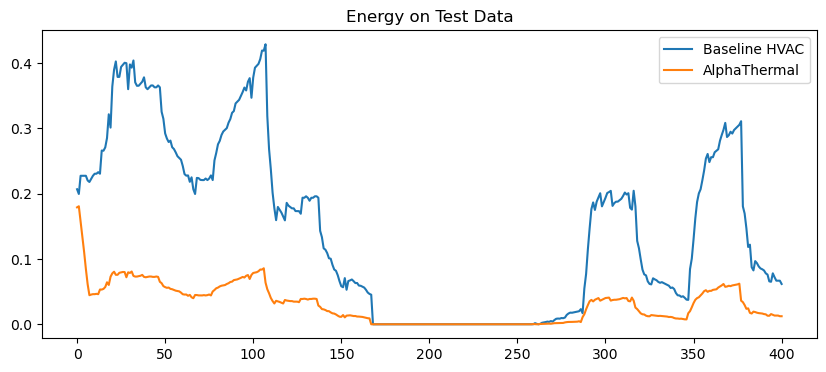

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(baseline_energy, label="Baseline HVAC")
plt.plot(model_energy, label="AlphaThermal")
plt.legend()
plt.title("Energy on Test Data")
plt.show()